In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce GTX 1650


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [4]:
df = pd.read_csv("/home/mohamed/Desktop/Data_Drive/master/master/Dataset/Combined Data/Combined_dataset.csv")


In [5]:
print("Shape:", df.shape)
df.head()
df.info()


Shape: (2827977, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           str    
 1   Area                              str    
 2   Waterbody Type                    str    
 3   Date                              str    
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          str    
dtypes: float64(9), str(5)
memory usage: 302.1 MB


In [6]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [7]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

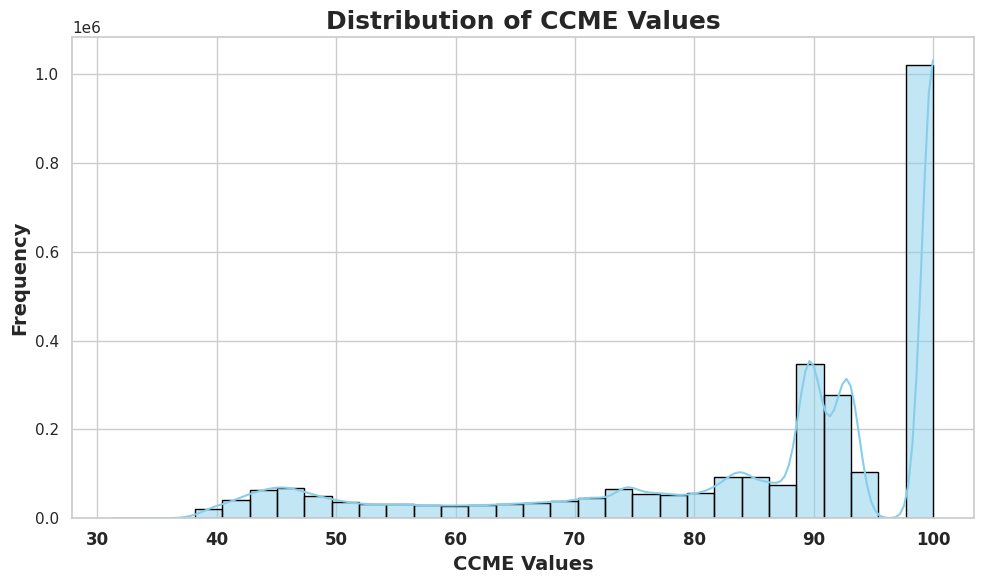

In [8]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



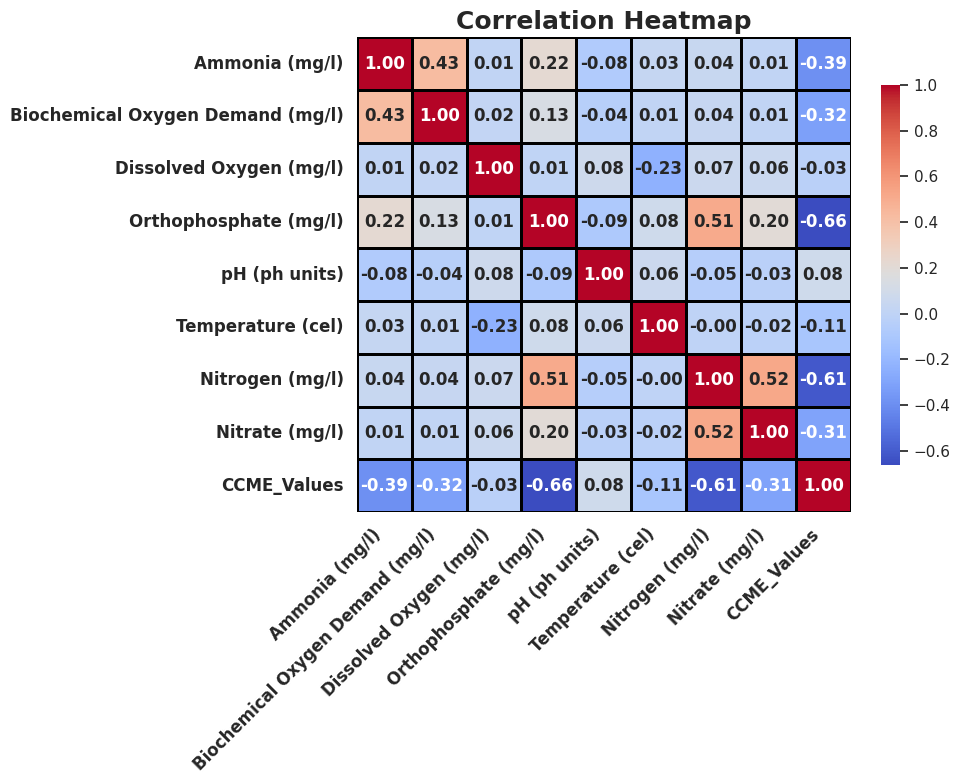

In [9]:

# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [10]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [11]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [12]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [13]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [ ]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")


# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


In [14]:
import joblib


X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [15]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [16]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   DPSGT – Dual Patch Savitzky-Golay Transformer
#   (Lin et al., IEEE IoT J. 2025)
#
# Architecture:
#   Input ──► SG Filter Trend Decomposition
#             ├── Trend X_bar  ──► DPSGT Cell ──┐
#             └── Detrend X_gamma ► DPSGT Cell ──┴─► Fusion ► Ŷ
#
#   DPSGT Cell:
#     Input ──► Global Patch + Local Patch
#             ──► Learnable Position Embedding
#             ──► Multi-Head Self-Attention
#             ──► FFN + Residual + LayerNorm
# ─────────────────────────────────────────────

import torch
import torch.nn as nn
import numpy as np

# ── 1. Savitzky-Golay Filter (Trend Decomposition) ──────────────────────────
class SGFilter(nn.Module):
    """
    Savitzky-Golay filter implemented as a 1-D convolution.
    Fits a polynomial of degree k over a window of size m using
    least-squares, then convolves the coefficients across the sequence.

    Input  : [B, T, F]
    Output : [B, T, F]  (smoothed trend)
    """
    def __init__(self, window_size: int = 10, poly_degree: int = 3):
        super().__init__()
        assert window_size % 2 == 0 or window_size > poly_degree, \
            "window_size must be > poly_degree"
        self.m = window_size
        self.k = poly_degree
        coeffs = self._sg_coeffs(window_size, poly_degree)  # [m]
        # Register as non-trainable buffer; shape [1, 1, m] for F.conv1d
        self.register_buffer('coeffs', coeffs.view(1, 1, -1))

    @staticmethod
    def _sg_coeffs(m: int, k: int) -> torch.Tensor:
        """Compute SG convolution coefficients via least-squares (eq. 3-7 in paper)."""
        half = m // 2
        z = torch.arange(-half, m - half, dtype=torch.float32)   # integer positions
        # Vandermonde matrix Z ∈ R^{m × k}
        Z = torch.stack([z ** i for i in range(k)], dim=1)        # [m, k]
        # Cζ = (Z^T Z)^{-1} Z^T   →  central row (index half) gives smoothing coeffs
        ZtZ_inv = torch.linalg.pinv(Z.T @ Z)
        C = ZtZ_inv @ Z.T                                          # [k, m]
        # The smoothed value at position ζ uses row-0 of C (constant term = mean)
        return C[0]                                                # [m]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, F]
        B, T, F = x.shape
        # Apply per-feature: merge B and F, convolve along T
        x_t = x.permute(0, 2, 1).reshape(B * F, 1, T)            # [B*F, 1, T]
        pad  = self.m // 2
        x_pad = torch.nn.functional.pad(x_t, (pad, pad), mode='replicate')
        trend = torch.nn.functional.conv1d(x_pad, self.coeffs)    # [B*F, 1, T]
        # Trim to original length (conv output may be T+1 due to even window)
        trend = trend[:, :, :T]
        return trend.reshape(B, F, T).permute(0, 2, 1)            # [B, T, F]


# ── 2. Patch Embedding ────────────────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """
    Divides the time series into overlapping patches (eq. 8-9 in paper).
    Supports both local (small P) and global (large P) patch lengths.

    Input  : [B, T, F]
    Output : [B, N, D]  where N = number of patches, D = d_model
    """
    def __init__(self, input_dim: int, patch_len: int, stride: int, d_model: int):
        super().__init__()
        self.patch_len = patch_len
        self.stride    = stride
        # Learnable linear projection: P*F → D  (eq. 9: x̃_p = W_p x̄_p + W_pos)
        self.proj = nn.Linear(patch_len * input_dim, d_model)
        # Learnable positional encoding (W_pos in eq. 9), lazy-init in forward
        self.pos_embed = None
        self.d_model   = d_model

    def _get_pos_embed(self, n_patches: int, device):
        if self.pos_embed is None or self.pos_embed.size(1) != n_patches:
            self.pos_embed = nn.Parameter(
                torch.zeros(1, n_patches, self.d_model, device=device)
            )
            nn.init.trunc_normal_(self.pos_embed, std=0.02)
        return self.pos_embed.to(device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, F]
        B, T, F = x.shape
        P, S = self.patch_len, self.stride
        # Pad end so every value is covered (paper: "fill final value to end")
        n_patches = max(1, (T - P) // S + 2)
        pad_len   = (n_patches - 1) * S + P - T
        if pad_len > 0:
            x = torch.cat([x, x[:, -1:, :].expand(B, pad_len, F)], dim=1)
        # Extract patches: [B, N, P*F]
        patches = x.unfold(1, P, S)                  # [B, N, F, P]  — unfold on T
        # unfold gives [B, n_patches, F, P] — need [B, n_patches, P*F]
        # Actually unfold(dimension=1, size=P, step=S) → [B, N, F, P] only if
        # we iterate over features; simpler: reshape after permute
        # Re-do correctly:
        x2 = x                                       # [B, T+pad, F]
        cols = []
        for i in range(n_patches):
            start = i * S
            cols.append(x2[:, start:start + P, :])  # [B, P, F]
        patches = torch.stack(cols, dim=1)           # [B, N, P, F]
        patches = patches.reshape(B, n_patches, P * F)  # [B, N, P*F]

        out = self.proj(patches)                      # [B, N, D]
        out = out + self._get_pos_embed(n_patches, x.device)
        return out                                    # [B, N, D]


# ── 3. DPSGT Cell ────────────────────────────────────────────────────────────
class DPSGTCell(nn.Module):
    """
    Single DPSGT processing cell (one branch: trend or detrend).
    Uses dual patches (local + global) fed into a shared Transformer encoder.

    Input  : [B, T, F]
    Output : [B, D]   (pooled representation)
    """
    def __init__(self, input_dim: int, d_model: int = 64,
                 n_heads: int = 4, n_layers: int = 2,
                 local_patch: int = 8, global_patch: int = 16,
                 stride: int = 4, dropout: float = 0.1):
        super().__init__()
        # Dual patch embeddings (eq. 8-9)
        self.local_embed  = PatchEmbedding(input_dim, local_patch,  stride, d_model)
        self.global_embed = PatchEmbedding(input_dim, global_patch, stride, d_model)

        # Transformer encoder (shared for both patch streams after concat)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
            norm_first=False   # Post-LN as in original Transformer
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm    = nn.LayerNorm(d_model)
        self.pool    = nn.AdaptiveAvgPool1d(1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, F]
        local_tok  = self.local_embed(x)   # [B, N_l, D]
        global_tok = self.global_embed(x)  # [B, N_g, D]

        # Concatenate local + global tokens along sequence dim
        tokens = torch.cat([local_tok, global_tok], dim=1)  # [B, N_l+N_g, D]

        # Transformer: capture temporal dependencies (eq. 10-13)
        H = self.encoder(tokens)           # [B, N, D]
        H = self.norm(H)

        # Global pooling → fixed-size representation
        H_t  = H.transpose(1, 2)          # [B, D, N]
        out  = self.pool(H_t).squeeze(-1) # [B, D]
        return out                         # H_bar in paper


# ── 4. Full DPSGT Model ───────────────────────────────────────────────────────
class DPSGT(nn.Module):
    """
    DPSGT – Dual Patch Savitzky-Golay Transformer
    for Water Quality / Time Series Regression.

    Architecture (Fig. 2 in paper):
        X ──► SG Filter ──► X_bar (trend)    ──► DPSGT Cell ──► H_bar_trend
               │         └► X_gamma (detrend) ──► DPSGT Cell ──► H_bar_detrend
               │
               └──► Fusion: Ŷ = W_y (H_bar_trend + H_bar_detrend) + b_y  (eq. 14)

    Parameters
    ----------
    input_dim    : number of input features F
    d_model      : hidden dimension D
    n_heads      : number of attention heads ξ
    n_layers     : transformer layers L
    local_patch  : local patch length P_l
    global_patch : global patch length P_g
    stride       : patch stride S
    sg_window    : SG filter window width m
    sg_degree    : SG filter polynomial degree k
    dropout      : dropout rate
    output_dim   : regression output size (1 for CCME)
    """
    def __init__(self, input_dim: int,
                 d_model: int = 64,
                 n_heads: int = 4,
                 n_layers: int = 2,
                 local_patch: int = 8,
                 global_patch: int = 16,
                 stride: int = 4,
                 sg_window: int = 10,
                 sg_degree: int = 3,
                 dropout: float = 0.1,
                 output_dim: int = 1):
        super().__init__()
        self.input_dim = input_dim
        self.d_model   = d_model

        # ── Trend decomposition (Section III-B1) ──
        self.sg_filter = SGFilter(window_size=sg_window, poly_degree=sg_degree)

        # ── Two independent DPSGT cells (trend + detrend) ──
        cell_kwargs = dict(
            input_dim=input_dim, d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, local_patch=local_patch,
            global_patch=global_patch, stride=stride, dropout=dropout
        )
        self.trend_cell   = DPSGTCell(**cell_kwargs)
        self.detrend_cell = DPSGTCell(**cell_kwargs)

        # ── Fusion head (eq. 14): Ŷ = F(H_bar_trend + H_bar_detrend) ──
        self.regressor = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(d_model // 2, output_dim)
        )

        # For XAI compatibility: store dummy attention weights
        self.last_attn_weights = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, F]

        # ── Step 1: SG-filter trend decomposition (eq. 1-2) ──
        x_trend   = self.sg_filter(x)          # X_bar   (smooth trend)
        x_detrend = x - x_trend                # X_gamma (residual/detrend)

        # ── Step 2: Feed each branch through its DPSGT cell (eq. 3-13) ──
        h_trend   = self.trend_cell(x_trend)   # [B, D]
        h_detrend = self.detrend_cell(x_detrend) # [B, D]

        # ── Step 3: Fusion (eq. 14) ──
        fused = h_trend + h_detrend            # element-wise sum
        out   = self.regressor(fused)          # [B, output_dim]

        # Dummy attention weights for XAI sections (shape compatible)
        B, T, F = x.shape
        self.last_attn_weights = torch.zeros(B, T, T, device=x.device)

        return out


# ── Instantiate model ─────────────────────────────────────────────────────────
input_size = X_train_seq.shape[2]
output_dim = 1

model = DPSGT(
    input_dim    = input_size,
    d_model      = 128,         # hidden size D
    n_heads      = 8,           # attention heads ξ
    n_layers     = 2,           # transformer layers L
    local_patch  = 8,           # local patch length P_l
    global_patch = 16,          # global patch length P_g
    stride       = 4,           # stride S
    sg_window    = 10,          # SG window m
    sg_degree    = 3,           # SG polynomial degree k
    dropout      = 0.10,
    output_dim   = output_dim
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model : DPSGT (Dual Patch Savitzky-Golay Transformer)")
print(f"Params: {num_params:,}")
print(f"Task  : Regression → predicting CCME_Values (0-100 continuous)")


Model : DPSGT (Dual Patch Savitzky-Golay Transformer)
Params: 917,505
Task  : Regression → predicting CCME_Values (0-100 continuous)


In [17]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=60,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 60
PATIENCE      = 6
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=60)
Early Stop   : patience=6, min_delta=0.01
Gradient Clip: 1.0


In [21]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [22]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:

        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] Resuming from: ./checkpoints/checkpoint_latest.pth
[Checkpoint] Scheduler state restored.
[Checkpoint] Resumed at epoch 28 | Best Val MSE so far: 3.1188 | History loaded: 28 epochs

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------


29      |5.7052            |3.7862            |0.000615  


30      |5.5740            |4.8837            |0.000587  


31      |5.4191            |3.7276            |0.000558  


32      |5.3228            |4.1567            |0.000529  


33      |5.1993            |3.3457            |0.000500  


34      |5.0751            |3.1898            |0.000471  

⚡ Early stopping at epoch 34
Best Val Loss: 3.1188
Total epochs trained: 34


<All keys matched successfully>

In [23]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)

        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  3.0836
Test RMSE: 1.7560
Test MAE:  0.9026
Test R2:   0.9886


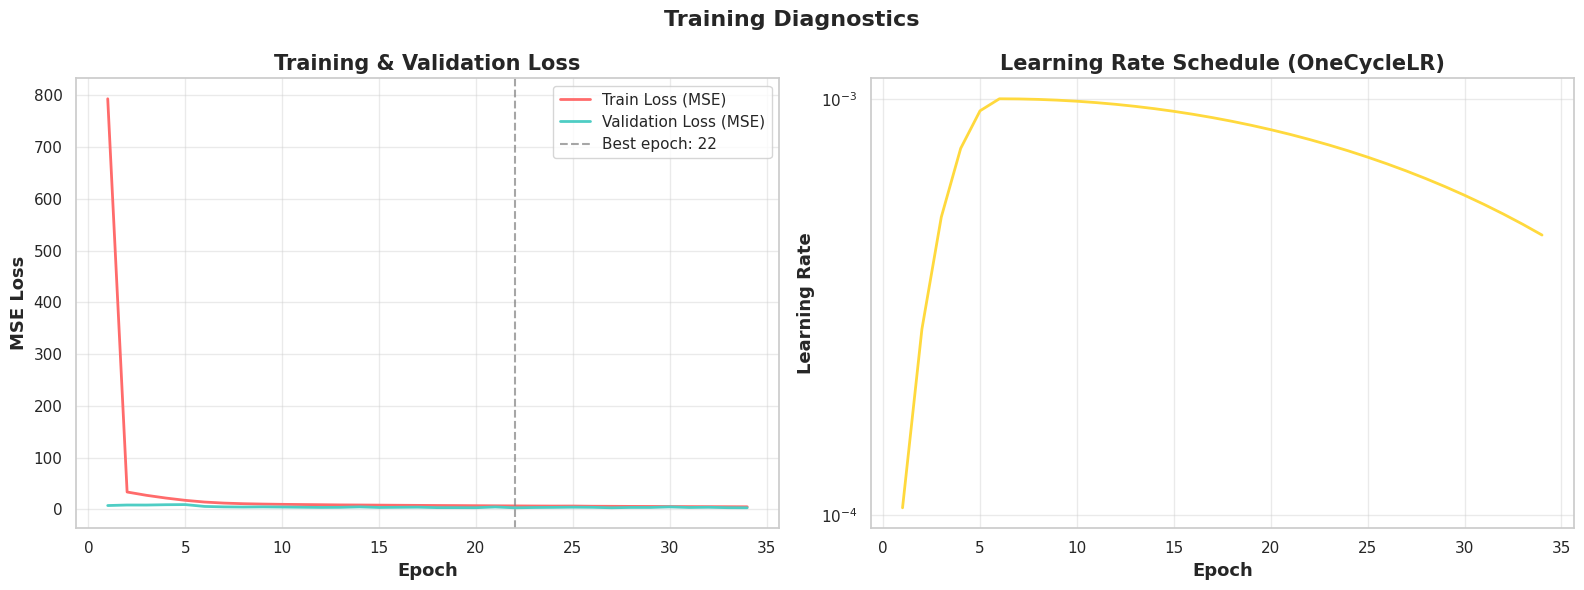

Best Val Loss: 3.1188 at epoch 22
Final Train Loss: 5.0751
Final Val Loss:   3.1898


In [24]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


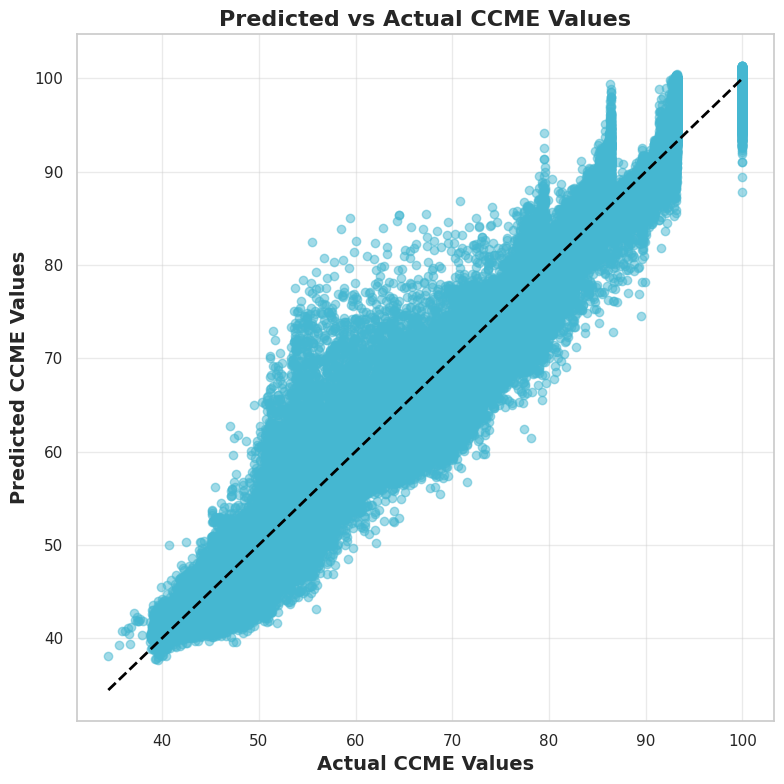

In [25]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



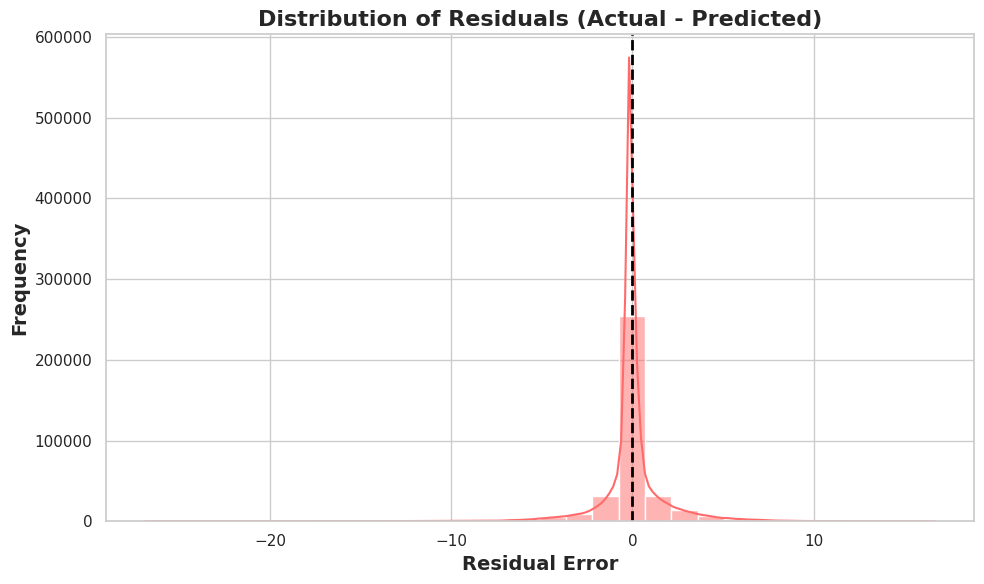

In [26]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()




  REGRESSION METRICS — CCME_Values Prediction
  Metric  Value                                      Description
     MSE 3.0836   Mean Squared Error – average squared deviation
    RMSE 1.7560 Root Mean Squared Error – in original CCME units
     MAE 0.9026 Mean Absolute Error – average absolute deviation
R² Score 0.9886 Coefficient of Determination – 1.0 = perfect fit


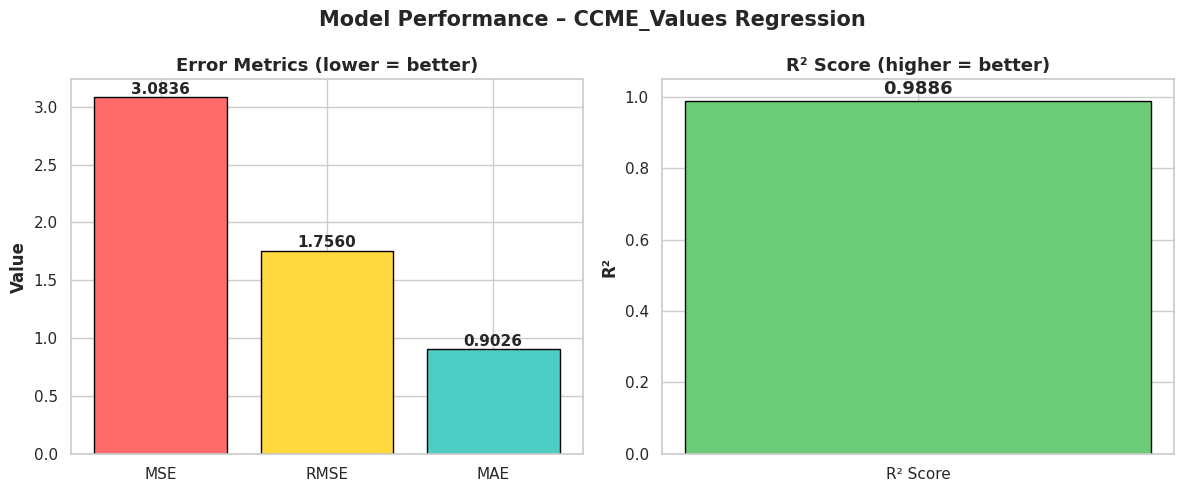

In [27]:
# ─────────────────────────────────────────────
# SECTION 14: Regression Metrics Summary Table
# ─────────────────────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value':  [test_mse, test_rmse, test_mae, test_r2],
    'Description': [
        'Mean Squared Error – average squared deviation',
        'Root Mean Squared Error – in original CCME units',
        'Mean Absolute Error – average absolute deviation',
        'Coefficient of Determination – 1.0 = perfect fit'
    ]
})
metrics_df['Value'] = metrics_df['Value'].round(4)

print("\n" + "="*60)
print("  REGRESSION METRICS — CCME_Values Prediction")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# Visual bar chart of error metrics (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

error_names  = ['MSE', 'RMSE', 'MAE']
error_values = [test_mse, test_rmse, test_mae]
axes[0].bar(error_names, error_values, color=['#FF6B6B', '#FFD93D', '#4ECDC4'],
            edgecolor='black')
axes[0].set_title('Error Metrics (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
for i, v in enumerate(error_values):
    axes[0].text(i, v + 0.01 * max(error_values), f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['R² Score'], [test_r2], color='#6BCB77', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[1].text(0, test_r2 + 0.02, f'{test_r2:.4f}', ha='center',
             fontsize=13, fontweight='bold')

plt.suptitle('Model Performance – CCME_Values Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] Extracting Attention Rollout Heatmaps...
['Ammonia_mg_l', 'Biochemical_Oxygen_Demand_mg_l', 'Dissolved_Oxygen_mg_l', 'Orthophosphate_mg_l', 'pH_ph_units', 'Temperature_cel', 'Nitrogen_mg_l', 'Nitrate_mg_l', 'Month_sin', 'Month_cos', 'Waterbody_Type_Artificial', 'Waterbody_Type_Coastal_Marine', 'Waterbody_Type_Lake', 'Waterbody_Type_Minor_Waterbodies', 'Waterbody_Type_River', 'Waterbody_Type_Wastewater']


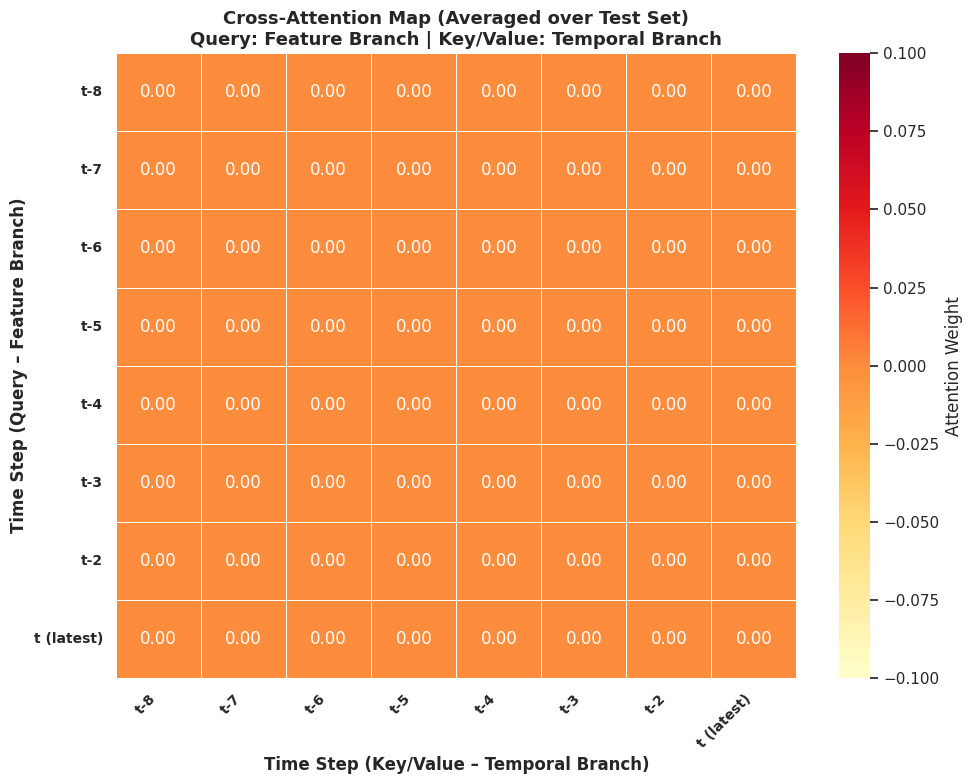

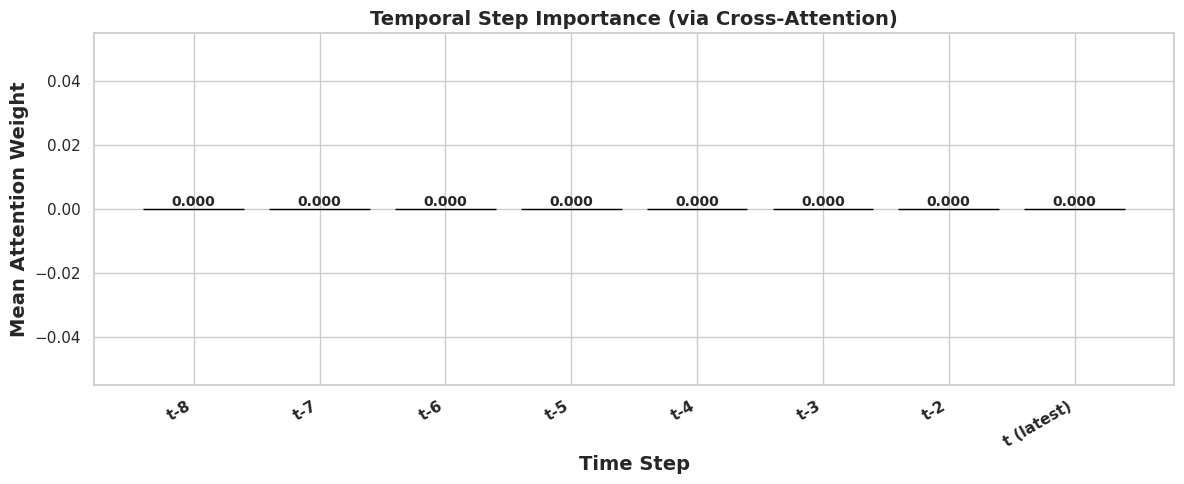

In [28]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – Attention Rollout Heatmap
# ─────────────────────────────────────────────
print("\n[XAI] Extracting Attention Rollout Heatmaps...")
SEQ_LEN = 8
feature_names = X_train.columns.tolist()
print(feature_names)
model.eval()

attn_maps_all = []   # collect over test batches
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)
        attn_maps_all.append(model.last_attn_weights.cpu().numpy())  # [B, T, T]

attn_maps_all = np.concatenate(attn_maps_all, axis=0)   # [N, T, T]

# Global: mean cross-attention over test set
mean_attn = attn_maps_all.mean(axis=0)    # [T, T]

# ── أسماء خطوات الزمن بدل الأرقام ──
time_step_labels = [f"t-{SEQ_LEN - i}" if i < SEQ_LEN - 1 else "t (latest)"
                    for i in range(SEQ_LEN)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mean_attn, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attention Weight'},
            xticklabels=time_step_labels,   # ← أسماء محور X
            yticklabels=time_step_labels)   # ← أسماء محور Y
ax.set_title('Cross-Attention Map (Averaged over Test Set)\n'
             'Query: Feature Branch | Key/Value: Temporal Branch',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step (Key/Value – Temporal Branch)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time Step (Query – Feature Branch)',       fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,   fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-time-step importance vector – بأسماء الخطوات
time_importance = mean_attn.mean(axis=0)   # [T]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(time_step_labels, time_importance, color='#4ECDC4', edgecolor='black')
for bar, val in zip(bars, time_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Attention Weight', fontsize=14, fontweight='bold')
ax.set_title('Temporal Step Importance (via Cross-Attention)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(time_step_labels, rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()



[XAI] SHAP Gradient Explainer...
shap_values shape after normalization: (50, 8, 16)


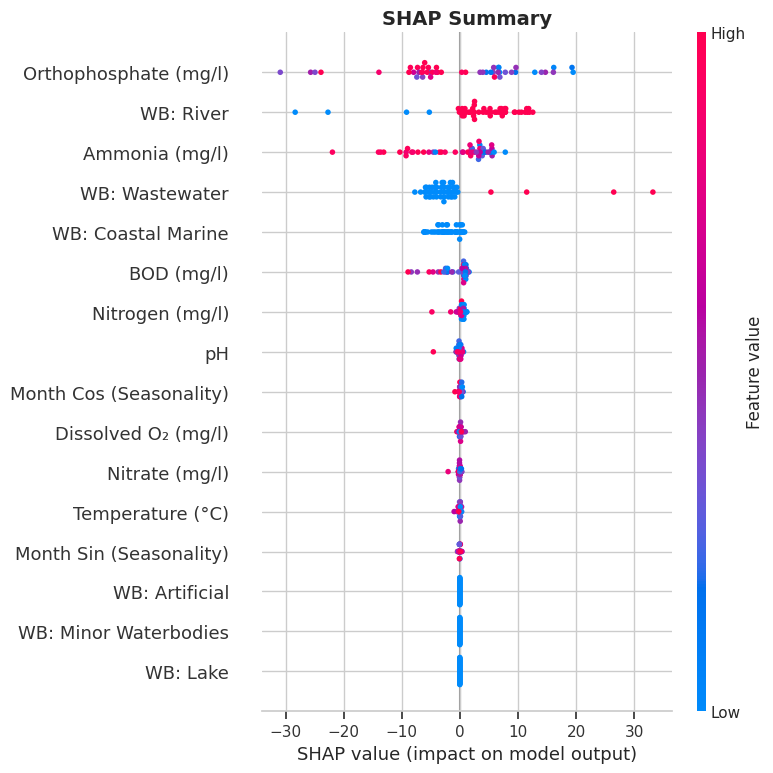

shap_means shape: (16,) | len features: 16


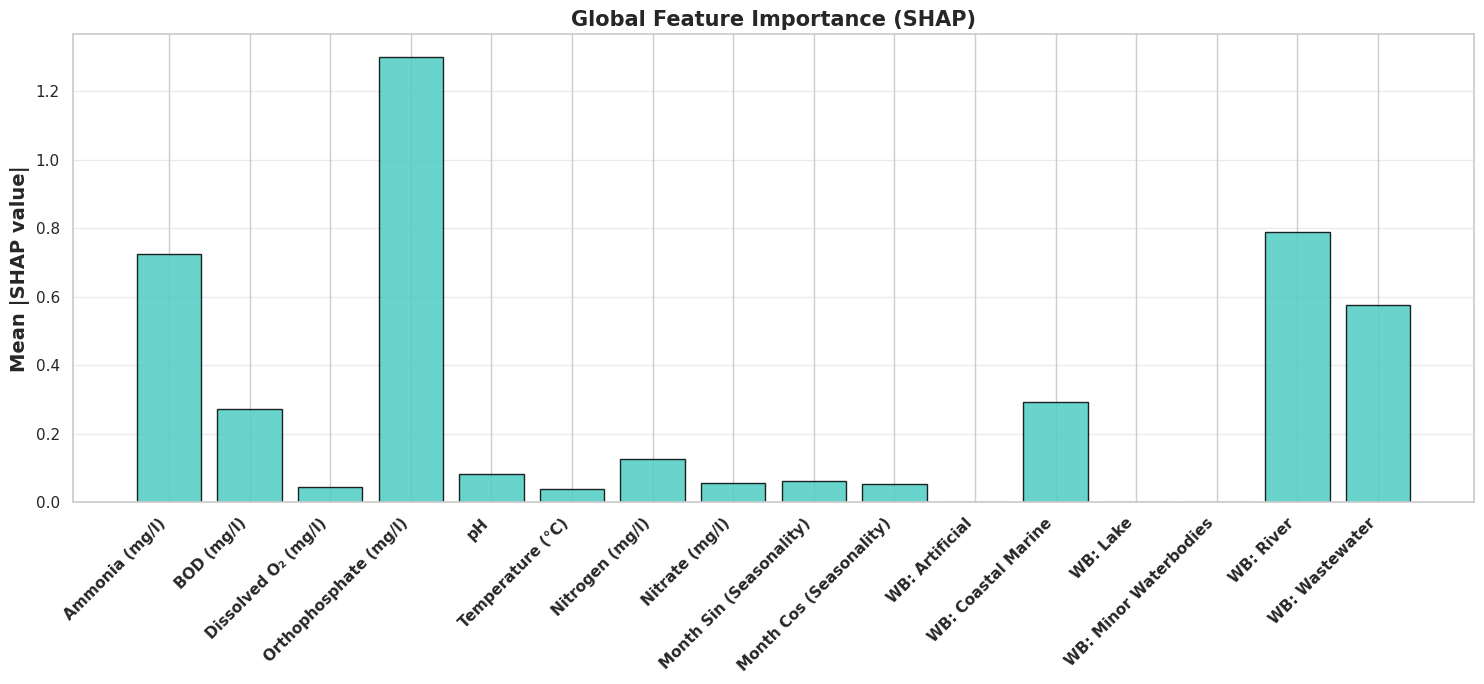

In [29]:

# ─────────────────────────────────────────────
# SECTION 16: XAI – SHAP GradientExplainer
# ─────────────────────────────────────────────
import shap
import numpy as np

print("\n[XAI] SHAP Gradient Explainer...")
background  = X_train_t[:100].to(device)
explainer   = shap.GradientExplainer(model, background)
test_sample = X_test_t[:50]   # already on device

shap_raw = explainer.shap_values(test_sample)

# ──────────────────────────────────────────────────────────────────────
# ✅ ROBUST FIX: Normalize shap_values to shape [N, T, F] regardless of
# what SHAP version returns. Possible raw shapes:
#   • list of [N, T, F]        ← SHAP < 0.40
#   • list of [N, T, F, 1]     ← SHAP 0.40-0.41
#   • ndarray [N, T, F]        ← some versions
#   • ndarray [N, T, F, 1]     ← other versions
# ──────────────────────────────────────────────────────────────────────
def normalize_shap(sv):
    """Always returns a plain float64 ndarray of shape [N, T, F]."""
    # Step 1: unwrap list → take first element (single-output model)
    if isinstance(sv, list):
        sv = sv[0]
    # Step 2: convert to numpy float64 (handles torch tensors too)
    sv = np.asarray(sv, dtype=np.float64)
    # Step 3: squeeze any trailing size-1 dims until we reach 3D [N, T, F]
    while sv.ndim > 3:
        if sv.shape[-1] == 1:
            sv = sv[..., 0]   # drop trailing output-dim
        elif sv.shape[0] == 1:
            sv = sv[0]        # drop leading wrapper-dim
        else:
            break             # unexpected shape — stop and let print below show it
    return sv

shap_values = normalize_shap(shap_raw)
print(f"shap_values shape after normalization: {shap_values.shape}")
# Expected: (50, 8, F)  where F = number of features
assert shap_values.ndim == 3, f"Unexpected SHAP shape: {shap_values.shape}"

# ── Feature name mapping ─────────────────────────────────────────────
raw_feature_names = X_train.columns.tolist()
feature_name_map = {
    'Ammonia_mg_l':                    'Ammonia (mg/l)',
    'Biochemical_Oxygen_Demand_mg_l':  'BOD (mg/l)',
    'Dissolved_Oxygen_mg_l':           'Dissolved O₂ (mg/l)',
    'Orthophosphate_mg_l':             'Orthophosphate (mg/l)',
    'pH_ph_units':                     'pH',
    'Temperature_cel':                 'Temperature (°C)',
    'Nitrogen_mg_l':                   'Nitrogen (mg/l)',
    'Nitrate_mg_l':                    'Nitrate (mg/l)',
    'Month_sin':                       'Month Sin (Seasonality)',
    'Month_cos':                       'Month Cos (Seasonality)',
}
feature_names_display = [
    feature_name_map.get(c, c.replace('_', ' ').replace('Waterbody Type ', 'WB: '))
    for c in raw_feature_names
]

# ── SHAP Summary Plot ────────────────────────────────────────────────
test_np  = test_sample.cpu().numpy()
input_2d = test_np.mean(axis=1)       # [50, T, F] → mean over T → [50, F]
sv_2d    = shap_values.sum(axis=1)    # [50, T, F] → sum  over T → [50, F]

plt.figure(figsize=(11, 7))
shap.summary_plot(sv_2d, input_2d, feature_names=feature_names_display, show=False)
plt.title("SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Global Feature Importance Bar ───────────────────────────────────
# mean over N (samples) and T (time steps) → 1-D array of shape [F]
shap_means = np.abs(shap_values).mean(axis=(0, 1)).flatten()  # always 1-D ✅
print(f"shap_means shape: {shap_means.shape} | len features: {len(feature_names_display)}")

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(feature_names_display))
ax.bar(x, shap_means, color='#4ECDC4', edgecolor='black', alpha=0.85)

ax.set_ylabel('Mean |SHAP value|', fontsize=14, fontweight='bold')
ax.set_title('Global Feature Importance (SHAP)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, rotation=45, ha='right',
                   fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('global_feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()


In [30]:

# ─────────────────────────────────────────────
# SECTION 17: XAI – Local Explanation Report
# ─────────────────────────────────────────────
print("\n[XAI] Local Explanations (5 test samples):")
print("="*80)

for sample_idx in range(5):
    true_val = t_targets[sample_idx]
    pred_val = t_preds[sample_idx]

    # Feature importance summed across time
    sv = shap_values[sample_idx]         # [T, F]
    sv_sum = sv.sum(axis=0)              # [F]
    top_k  = np.argsort(np.abs(sv_sum))[::-1][:3] # top-3

    top_feats = [(feature_names_display[i], sv_sum[i]) for i in top_k]
    feat_str  = ", ".join([f"{n}({'↑' if v > 0 else '↓'}{abs(v):.3f})"
                           for n, v in top_feats])

    print(f"Sample {sample_idx+1}: True CCME={true_val:.2f} | Pred={pred_val:.2f}")
    print(f"   → Key drivers: {feat_str}\n")




[XAI] Local Explanations (5 test samples):
Sample 1: True CCME=89.63 | Pred=87.77
   → Key drivers: Orthophosphate (mg/l)(↑5.340), Ammonia (mg/l)(↑3.302), WB: Wastewater(↓2.008)

Sample 2: True CCME=89.63 | Pred=88.13
   → Key drivers: Orthophosphate (mg/l)(↑4.552), WB: River(↑2.368), Ammonia (mg/l)(↑1.643)

Sample 3: True CCME=74.34 | Pred=74.34
   → Key drivers: Orthophosphate (mg/l)(↓5.120), WB: River(↑4.015), WB: Wastewater(↓2.737)

Sample 4: True CCME=71.68 | Pred=72.82
   → Key drivers: Orthophosphate (mg/l)(↓7.400), WB: River(↑4.926), WB: Wastewater(↓2.789)

Sample 5: True CCME=71.74 | Pred=74.28
   → Key drivers: Orthophosphate (mg/l)(↓6.400), WB: River(↑6.062), WB: Wastewater(↓4.356)



In [31]:

# ─────────────────────────────────────────────
# SECTION 18: DiCE – Counterfactual Explanations
# ─────────────────────────────────────────────
# DiCE for Regression is possible but requires different parameters.
# Disabled for now.
print("\n[DiCE] Disabled for regression.")




[DiCE] Disabled for regression.



ABLATION STUDY – DPSGT Components
  [DPSGT-noSG (Moving Avg only)]  RMSE=1.7931  MAE=1.0260
  [DPSGT-noDualPatch (single patch)]  RMSE=2.4228  MAE=1.5102
  [Full DPSGT]  RMSE=2.2305  MAE=1.3990


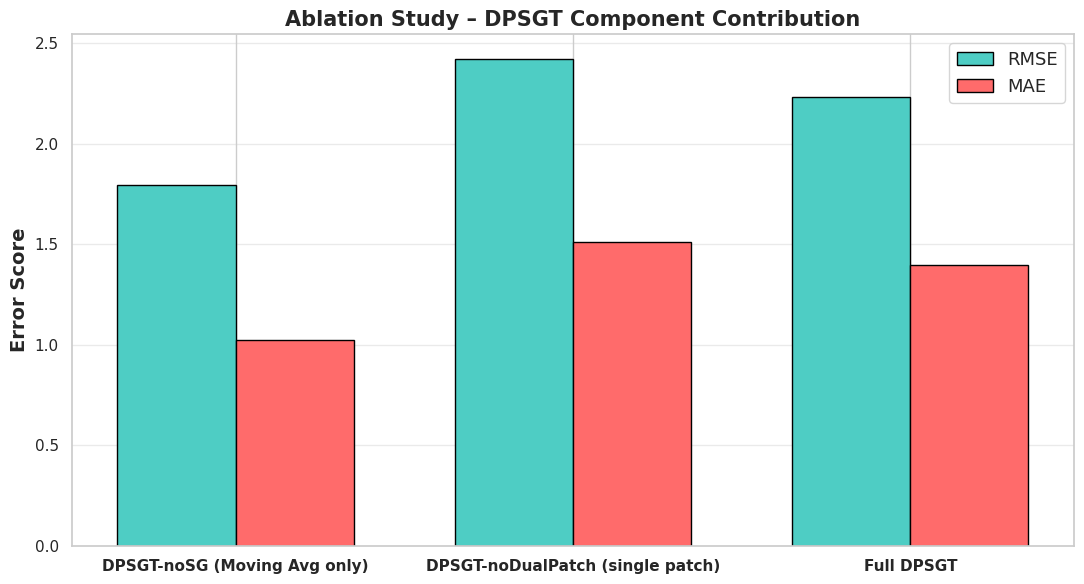

In [32]:
# ─────────────────────────────────────────────
# SECTION 19: Ablation Study
# ─────────────────────────────────────────────
print("\n" + "="*80)
print("ABLATION STUDY – DPSGT Components")
print("="*80)


class AblationDPSGT(nn.Module):
    """Stripped-down DPSGT for ablation: toggle SG filter and dual-patch."""
    def __init__(self, input_dim, d_model=64, n_heads=4, n_layers=2,
                 output_dim=1, dropout=0.1,
                 use_sg=True, use_dual_patch=True):
        super().__init__()
        self.use_sg         = use_sg
        self.use_dual_patch = use_dual_patch
        self.d_model        = d_model

        if use_sg:
            self.sg_filter = SGFilter(window_size=10, poly_degree=3)

        cell_kwargs = dict(
            input_dim=input_dim, d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, local_patch=8,
            global_patch=16 if use_dual_patch else 8,
            stride=4, dropout=dropout
        )
        self.trend_cell   = DPSGTCell(**cell_kwargs)
        self.detrend_cell = DPSGTCell(**cell_kwargs) if use_sg else None

        self.regressor = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, output_dim)
        )

    def forward(self, x):
        if self.use_sg:
            x_trend   = self.sg_filter(x)
            x_detrend = x - x_trend
            h = self.trend_cell(x_trend) + self.detrend_cell(x_detrend)
        else:
            h = self.trend_cell(x)
        return self.regressor(h)


def quick_train_eval(model_v, name, epochs=30):
    opt  = optim.AdamW(model_v.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.MSELoss()

    for ep in range(epochs):
        model_v.train()
        for bx, by in train_loader:
            bx = bx.to(device); by = by.to(device)
            loss = crit(model_v(bx), by)
            opt.zero_grad(); loss.backward(); opt.step()

    model_v.eval()
    preds_all, targs_all = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            preds_all.extend(model_v(bx).cpu().numpy().flatten())
            targs_all.extend(by.cpu().numpy().flatten())

    rmse = np.sqrt(mean_squared_error(targs_all, preds_all))
    mae  = mean_absolute_error(targs_all, preds_all)
    print(f"  [{name}]  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return rmse, mae


configs = [
    ("DPSGT-noSG (Moving Avg only)",  False, True),
    ("DPSGT-noDualPatch (single patch)", True, False),
    ("Full DPSGT",                     True, True),
]

ablation_results = {}
for name, use_sg, use_dp in configs:
    m_abl = AblationDPSGT(input_size, d_model=64, n_heads=4,
                           n_layers=2, output_dim=1,
                           use_sg=use_sg, use_dual_patch=use_dp).to(device)
    rmse, mae = quick_train_eval(m_abl, name, epochs=4)
    ablation_results[name] = {"RMSE": rmse, "MAE": mae}

labels    = list(ablation_results.keys())
rmse_vals = [ablation_results[k]["RMSE"] for k in labels]
mae_vals  = [ablation_results[k]["MAE"]  for k in labels]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w/2, rmse_vals, w, label="RMSE", color="#4ECDC4", edgecolor="black")
ax.bar(x + w/2, mae_vals,  w, label="MAE",  color="#FF6B6B", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11, fontweight="bold")
ax.set_ylabel("Error Score", fontsize=14, fontweight="bold")
ax.set_title("Ablation Study – DPSGT Component Contribution",
             fontsize=15, fontweight="bold")
ax.legend(fontsize=13); ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("ablation_study.png", dpi=300, bbox_inches="tight")
plt.show()


In [33]:

# ─────────────────────────────────────────────
# SECTION 20: Final Summary
# ─────────────────────────────────────────────
print("\n" + "="*80)
print(" FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression")
print("="*80)
print(f"  Test MSE:   {test_mse:>8.4f}")
print(f"  Test RMSE:  {test_rmse:>8.4f}")
print(f"  Test MAE:   {test_mae:>8.4f}")
print(f"  R2 Score:   {test_r2:>8.4f}")
print("="*80)




 FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression
  Test MSE:     3.0836
  Test RMSE:    1.7560
  Test MAE:     0.9026
  R2 Score:     0.9886


In [ ]:
# End of notebook — Dual-Branch Transformer Regression on CCME_Values
